Train Shape: (200, 7)
Test Shape: (80, 7)
Explained Variance Ratio: [0.20611048 0.18756502]

Logistic Regression
Accuracy: 0.3375

Decision Tree
Accuracy: 0.225

Random Forest
Accuracy: 0.2125


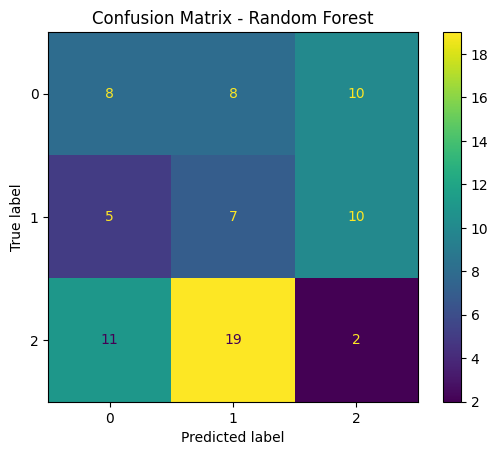

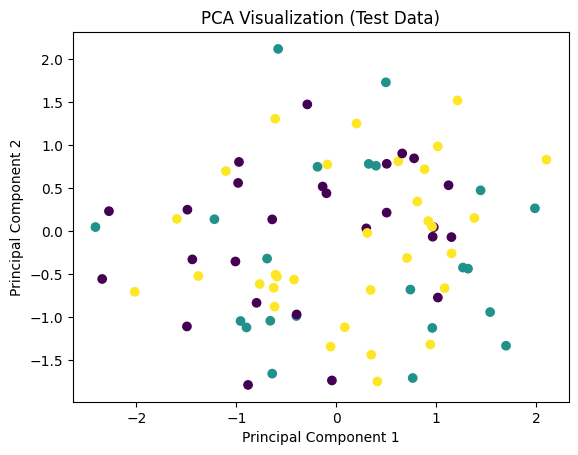

In [ ]:
# ==========================================
# Credit Risk Assessment (2 Dataset Version)
# ==========================================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ------------------------------
# Load Datasets
# ------------------------------
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# ------------------------------
# Combine for preprocessing
# ------------------------------
data = pd.concat([train, test], axis=0)

# ------------------------------
# Data Cleaning
# ------------------------------
data = data.dropna()

# ------------------------------
# Encode categorical columns
# ------------------------------
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col].astype(str))

# ------------------------------
# Split back into train & test
# ------------------------------
train = data.iloc[:len(train), :]
test = data.iloc[len(train):, :]

# ------------------------------
# Features & Target
# ------------------------------
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

# ------------------------------
# Feature Scaling
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# PCA (2 components)
# ------------------------------
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# ------------------------------
# Models
# ------------------------------

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_pca, y_train)
y_pred_lr = lr.predict(X_test_pca)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train_pca, y_train)
y_pred_dt = dt.predict(X_test_pca)

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)

# ------------------------------
# Evaluation Function
# ------------------------------
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))

# Evaluate all models
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")

# ------------------------------
# Confusion Matrix (Best Model)
# ------------------------------
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ------------------------------
# PCA Visualization
# ------------------------------
plt.figure()
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis')
plt.title("PCA Visualization (Test Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()